# STEP 2: UNIVARIATE & MULTIVARIATE ANALYSIS
## Phân tích Từng Biến & Tương quan Giữa Các Biến

### Outputs:
**Analysis Reports**:
- Univariate Analysis: Trend, Seasonality, Stationarity, Distribution
- Multivariate Analysis: Correlation, Rolling Correlation, Lag Correlation
- Granger Causality: Causal relationships between variables

**Figures**:
- ACF/PACF plots (Autocorrelation & Partial Autocorrelation)
- ADF/KPSS test results (Stationarity)
- Rolling correlation heatmaps (Time-varying relationships)
- Lag correlation plots (Lead-lag effects)
- Granger causality network

## Setup & Configuration

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os
import warnings
warnings.filterwarnings('ignore')

SCRIPT_DIR = os.path.dirname(os.path.abspath('step2_univariate_multivariate_analysis.ipynb'))
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"Data Directory: {DATA_DIR}")

Data Directory: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed


## Load Data

In [97]:
cleaned_data = pd.read_csv(os.path.join(DATA_DIR, 'cpi_02_06.csv'))
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
cleaned_data = cleaned_data.sort_values('date').reset_index(drop=True)

print(f"✓ Loaded cleaned data: {cleaned_data.shape[0]} months × {cleaned_data.shape[1]} columns")
print(f"Date range: {cleaned_data['date'].min().date()} to {cleaned_data['date'].max().date()}")
print(f"\nData Info:")
print(f"  Total records: {len(cleaned_data)}")
print(f"  Missing values: {cleaned_data.isnull().sum().sum()}")
print(f"  Numeric columns: {cleaned_data.select_dtypes(include=[np.number]).shape[1]}")

print(f"\nFirst 5 rows:")
print(cleaned_data.head())

✓ Loaded cleaned data: 360 months × 30 columns
Date range: 1995-01-01 to 2024-12-01

Data Info:
  Total records: 360
  Missing values: 0
  Numeric columns: 29

First 5 rows:
        date  cpi_mom_processed_cpi  cpi_mom_processed_inflation  \
0 1995-01-01                  103.8                          3.8   
1 1995-02-01                  103.4                          3.4   
2 1995-03-01                  100.2                          0.2   
3 1995-04-01                  101.0                          1.0   
4 1995-05-01                  101.8                          1.8   

   core_inflation_rate  interest_rate  ppi_qoq         m2  broad_money  \
0                  2.2           3.85    -0.73  1748226.0        3.567   
1                  2.2           3.85    -0.73  1748226.0        3.303   
2                  2.2           3.85    -0.73  1748226.0        3.495   
3                  2.2           3.85    -0.73  1748226.0        3.434   
4                  2.2           3.85    -0.73 

In [98]:
# dổi tên cột 
cleaned_data.rename(columns={'cpi_mom_processed_cpi': 'cpi_mom', 'cpi_mom_processed_inflation': 'cpi_mom_inflation'}, inplace=True)

## PART 1: UNIVARIATE ANALYSIS
### 1.1 Stationarity Tests (ADF & KPSS)

In [99]:

print("ADF Test (Augmented Dickey-Fuller): H0 = Non-stationary")
print("KPSS Test: H0 = Stationary")
numeric_cols = cleaned_data.select_dtypes(include=[np.number]).columns.tolist()

stationarity_results = []

for col in numeric_cols:
    series = cleaned_data[col].dropna()
    
    if len(series) < 10: 
        continue

    try:
        adf_result = adfuller(series, autolag='AIC')
        adf_stat = adf_result[0]
        adf_pval = adf_result[1]
        adf_lags = adf_result[2]
    except:
        adf_stat, adf_pval, adf_lags = np.nan, np.nan, np.nan

    try:
        kpss_result = kpss(series, regression='c', nlags='auto')
        kpss_stat = kpss_result[0]
        kpss_pval = kpss_result[1]
    except:
        kpss_stat, kpss_pval = np.nan, np.nan

    adf_stationary = "Yes" if adf_pval < 0.05 else "No"
    kpss_stationary = "Yes" if kpss_pval > 0.05 else "No"
    consensus = "Stationary" if (adf_pval < 0.05 and kpss_pval > 0.05) else "Non-Stationary"
    
    stationarity_results.append({
        'Variable': col,
        'ADF_Statistic': adf_stat,
        'ADF_p_value': adf_pval,
        'ADF_Stationary': adf_stationary,
        'KPSS_Statistic': kpss_stat,
        'KPSS_p_value': kpss_pval,
        'KPSS_Stationary': kpss_stationary,
        'Consensus': consensus
    })

stationarity_df = pd.DataFrame(stationarity_results)

print(f"\nStationary Variables (by consensus):")
stationary = stationarity_df[stationarity_df['Consensus'] == 'Stationary']
non_stationary = stationarity_df[stationarity_df['Consensus'] == 'Non-Stationary']

print(f"  ✓ Stationary: {len(stationary)} variables")
for idx, row in stationary.head(10).iterrows():
    print(f"    • {row['Variable']:20} (ADF p={row['ADF_p_value']:.4f}, KPSS p={row['KPSS_p_value']:.4f})")

print(f"\n  ✗ Non-Stationary: {len(non_stationary)} variables")
for idx, row in non_stationary[0:23].iterrows():
    print(f" {row['Variable']:20} (ADF p={row['ADF_p_value']:.4f}, KPSS p={row['KPSS_p_value']:.4f})")

ADF Test (Augmented Dickey-Fuller): H0 = Non-stationary
KPSS Test: H0 = Stationary

Stationary Variables (by consensus):
  ✓ Stationary: 7 variables
    • cpi_mom              (ADF p=0.0031, KPSS p=0.1000)
    • cpi_mom_inflation    (ADF p=0.0031, KPSS p=0.1000)
    • core_inflation_rate  (ADF p=0.0001, KPSS p=0.1000)
    • interest_rate        (ADF p=0.0000, KPSS p=0.1000)
    • brent                (ADF p=0.0042, KPSS p=0.1000)
    • month                (ADF p=0.0000, KPSS p=0.1000)
    • quarter              (ADF p=0.0000, KPSS p=0.1000)

  ✗ Non-Stationary: 22 variables
 ppi_qoq              (ADF p=0.3078, KPSS p=0.0100)
 m2                   (ADF p=0.9991, KPSS p=0.0100)
 broad_money          (ADF p=0.2806, KPSS p=0.0100)
 policy_rate          (ADF p=0.1211, KPSS p=0.0100)
 gdp                  (ADF p=0.9082, KPSS p=0.0100)
 wti                  (ADF p=0.1217, KPSS p=0.0100)
 gasoline_world       (ADF p=0.2521, KPSS p=0.0100)
 natural_gas          (ADF p=0.1804, KPSS p=0.0100)
 g

### 1.2 ACF & PACF Analysis (Top 6 Non-Stationary Variables)


[UNIVARIATE ANALYSIS] ACF & PACF PLOTS



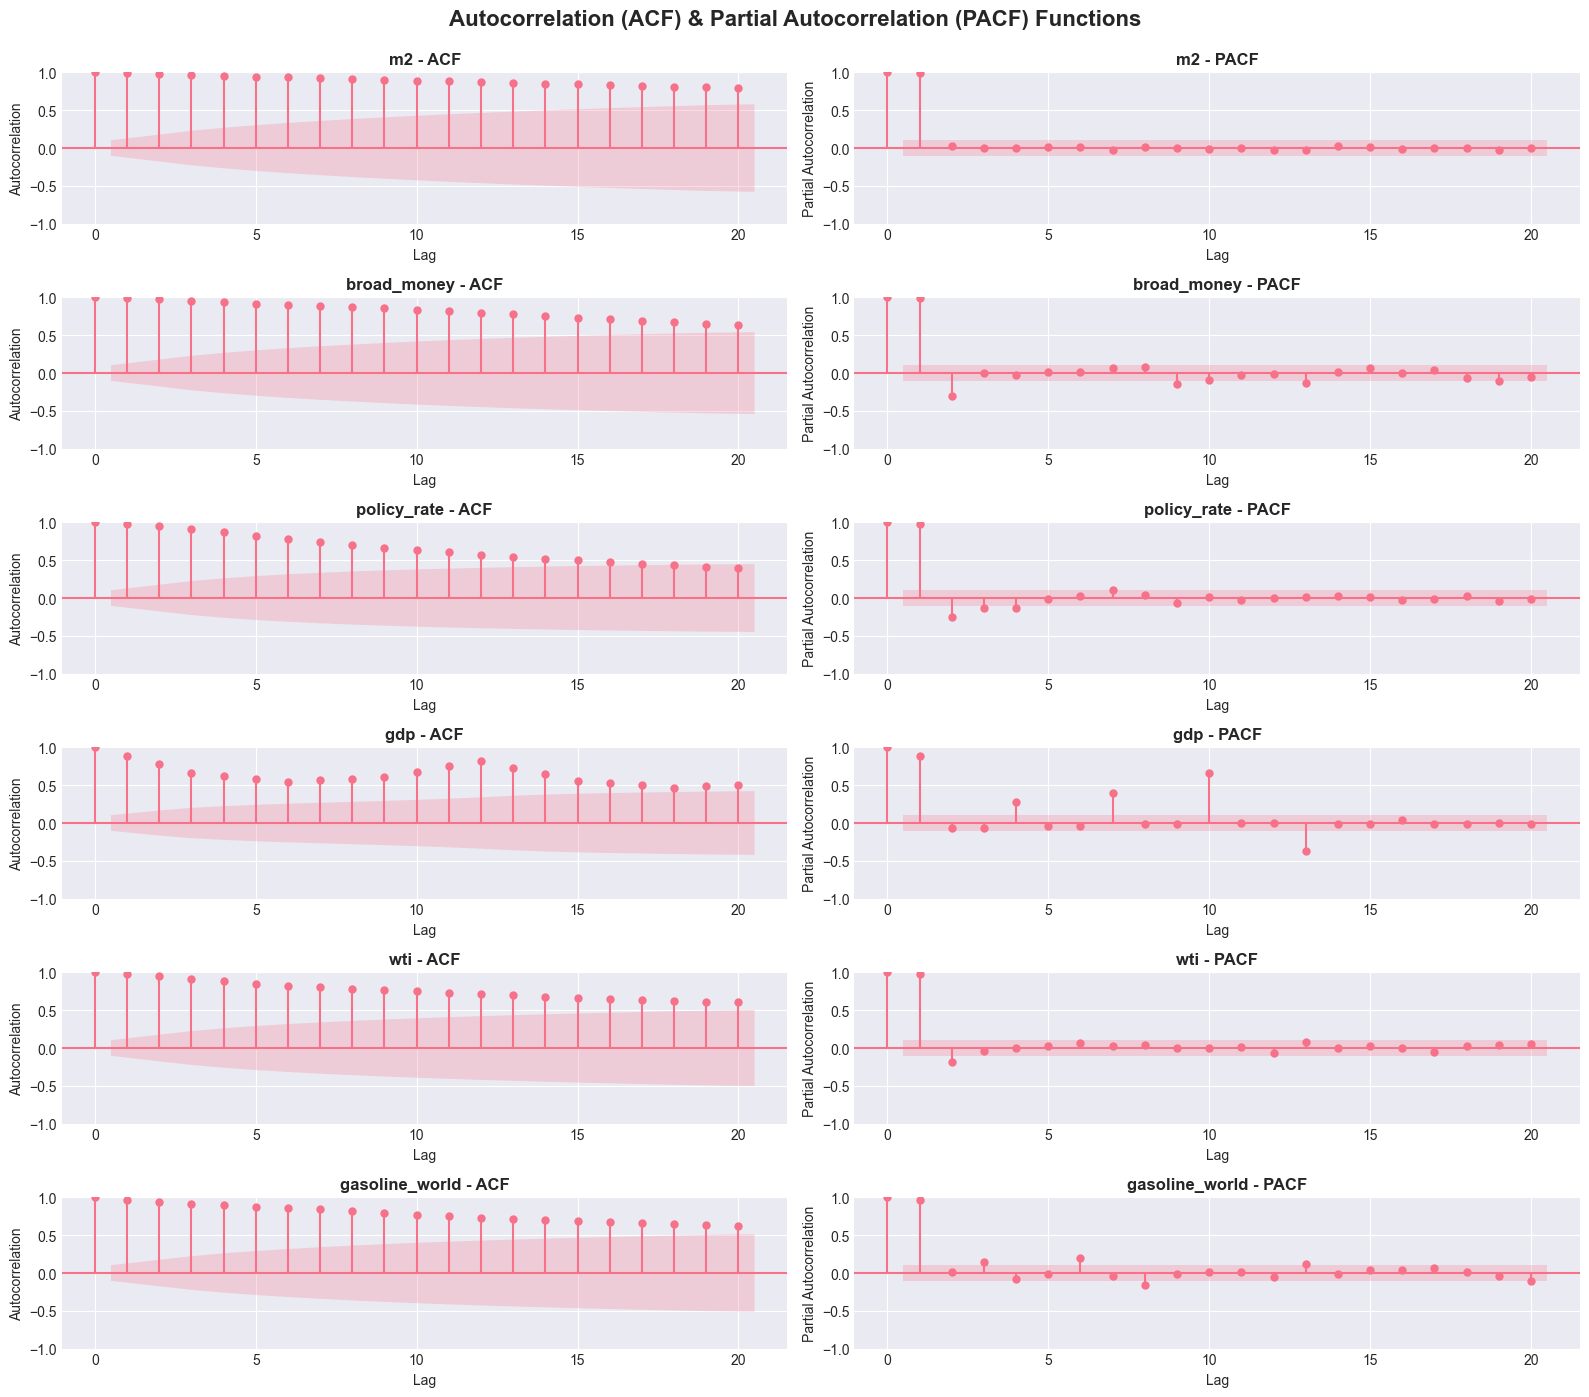


Interpretation:
  • ACF slowly decaying → Strong autocorrelation → Non-stationary
  • PACF significant at lag 1 → AR(1) process


In [100]:
print("\n[UNIVARIATE ANALYSIS] ACF & PACF PLOTS\n")

# Select top 6 non-stationary variables
top_nonstat = non_stationary['Variable'][1:7].tolist()

fig, axes = plt.subplots(len(top_nonstat), 2, figsize=(16, 14))
fig.suptitle('Autocorrelation (ACF) & Partial Autocorrelation (PACF) Functions', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(top_nonstat):
    series = cleaned_data[var].dropna()
    
    # ACF
    ax_acf = axes[idx, 0]
    plot_acf(series, lags=20, ax=ax_acf)
    ax_acf.set_title(f'{var} - ACF', fontweight='bold')
    ax_acf.set_xlabel('Lag')
    ax_acf.set_ylabel('Autocorrelation')
    
    # PACF
    ax_pacf = axes[idx, 1]
    plot_pacf(series, lags=20, ax=ax_pacf, method='ywm')
    ax_pacf.set_title(f'{var} - PACF', fontweight='bold')
    ax_pacf.set_xlabel('Lag')
    ax_pacf.set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  • ACF slowly decaying → Strong autocorrelation → Non-stationary")
print(f"  • PACF significant at lag 1 → AR(1) process")

In [82]:
# top_nonstat = non_stationary['Variable'][7:13].tolist()

# fig, axes = plt.subplots(len(top_nonstat), 2, figsize=(16, 14))
# fig.suptitle('Autocorrelation (ACF) & Partial Autocorrelation (PACF) Functions', 
#              fontsize=16, fontweight='bold', y=0.995)

# for idx, var in enumerate(top_nonstat):
#     series = cleaned_data[var].dropna()
    
#     # ACF
#     ax_acf = axes[idx, 0]
#     plot_acf(series, lags=20, ax=ax_acf)
#     ax_acf.set_title(f'{var} - ACF', fontweight='bold')
#     ax_acf.set_xlabel('Lag')
#     ax_acf.set_ylabel('Autocorrelation')
    
#     # PACF
#     ax_pacf = axes[idx, 1]
#     plot_pacf(series, lags=20, ax=ax_pacf, method='ywm')
#     ax_pacf.set_title(f'{var} - PACF', fontweight='bold')
#     ax_pacf.set_xlabel('Lag')
#     ax_pacf.set_ylabel('Partial Autocorrelation')

# plt.tight_layout()
# plt.show()

# print(f"\nInterpretation:")
# print(f"  • ACF slowly decaying → Strong autocorrelation → Non-stationary")
# print(f"  • PACF significant at lag 1 → AR(1) process")

In [83]:
# top_nonstat = non_stationary['Variable'][13:23].tolist()

# fig, axes = plt.subplots(len(top_nonstat), 2, figsize=(16, 14))
# fig.suptitle('Autocorrelation (ACF) & Partial Autocorrelation (PACF) Functions', 
#              fontsize=16, fontweight='bold', y=0.995)

# for idx, var in enumerate(top_nonstat):
#     series = cleaned_data[var].dropna()
    
#     # ACF
#     ax_acf = axes[idx, 0]
#     plot_acf(series, lags=20, ax=ax_acf)
#     ax_acf.set_title(f'{var} - ACF', fontweight='bold')
#     ax_acf.set_xlabel('Lag')
#     ax_acf.set_ylabel('Autocorrelation')
    
#     # PACF
#     ax_pacf = axes[idx, 1]
#     plot_pacf(series, lags=20, ax=ax_pacf, method='ywm')
#     ax_pacf.set_title(f'{var} - PACF', fontweight='bold')
#     ax_pacf.set_xlabel('Lag')
#     ax_pacf.set_ylabel('Partial Autocorrelation')

# plt.tight_layout()
# plt.show()

# print(f"\nInterpretation:")
# print(f"  • ACF slowly decaying → Strong autocorrelation → Non-stationary")
# print(f"  • PACF significant at lag 1 → AR(1) process")

### 1.2b CPI Seasonality Analysis (ACF Deep Dive)

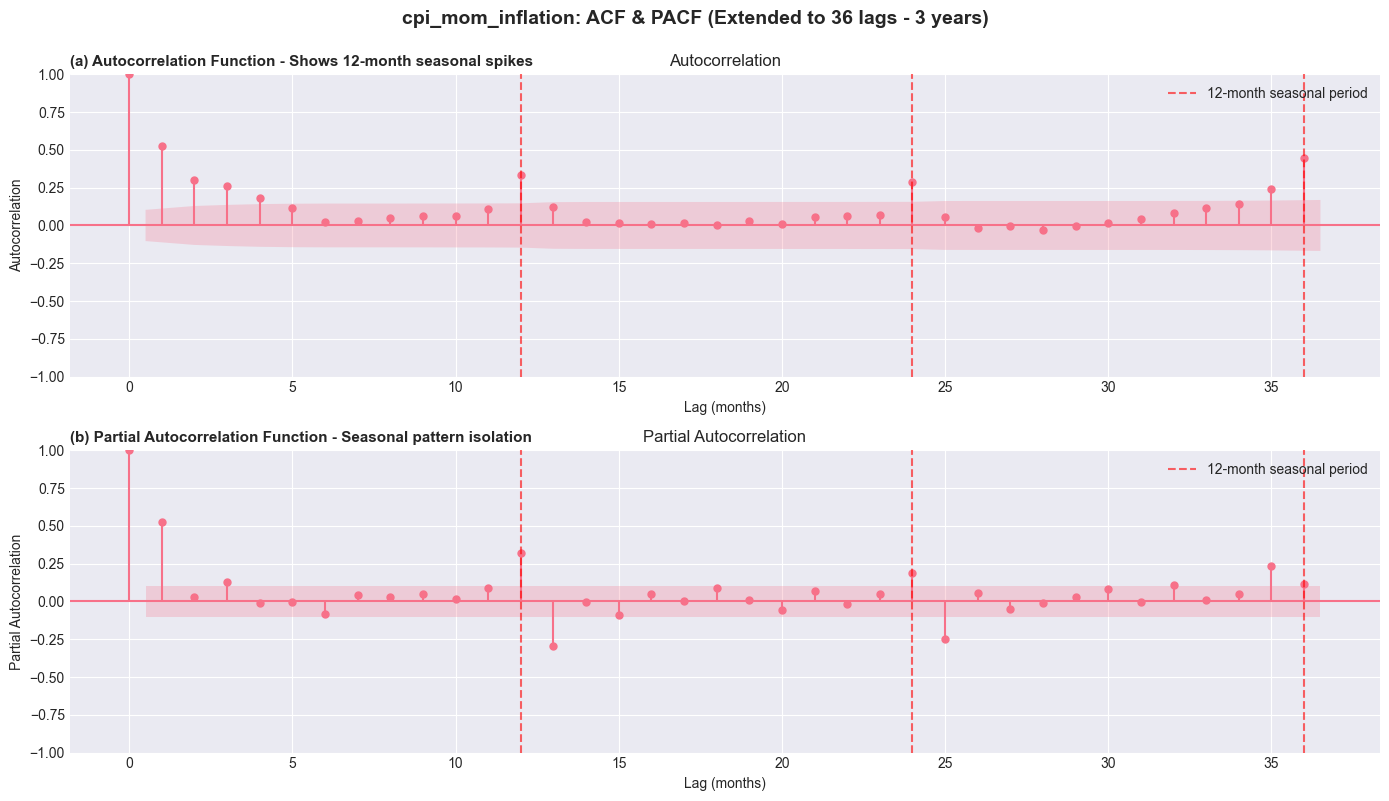

In [84]:
cpi_col = next((col for col in numeric_cols if 'cpi' in col.lower()), None)

if cpi_col:
    cpi_series = cleaned_data[cpi_col].dropna()

    cpi_adf = stationarity_df[stationarity_df['Variable'] == cpi_col]
    if len(cpi_adf) > 0:
        adf_pval = cpi_adf.iloc[0]['ADF_p_value']
        kpss_pval = cpi_adf.iloc[0]['KPSS_p_value']
        consensus = cpi_adf.iloc[0]['Consensus']

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(f'{cpi_col}: ACF & PACF (Extended to 36 lags - 3 years)', 
                 fontsize=14, fontweight='bold', y=0.995)

    plot_acf(cpi_series, lags=36, ax=axes[0])
    axes[0].set_title(f'(a) Autocorrelation Function - Shows 12-month seasonal spikes', 
                      fontsize=11, fontweight='bold', loc='left')
    axes[0].axvline(x=12, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='12-month seasonal period')
    axes[0].axvline(x=24, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
    axes[0].axvline(x=36, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
    axes[0].legend(loc='upper right')
    axes[0].set_xlabel('Lag (months)')
    axes[0].set_ylabel('Autocorrelation')

    plot_pacf(cpi_series, lags=36, ax=axes[1], method='ywm')
    axes[1].set_title(f'(b) Partial Autocorrelation Function - Seasonal pattern isolation', 
                      fontsize=11, fontweight='bold', loc='left')
    axes[1].axvline(x=12, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='12-month seasonal period')
    axes[1].axvline(x=24, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
    axes[1].axvline(x=36, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
    axes[1].legend(loc='upper right')
    axes[1].set_xlabel('Lag (months)')
    axes[1].set_ylabel('Partial Autocorrelation')
    
    plt.tight_layout()
    plt.show()

else:
    print(f"CPI column not found. Available columns: {numeric_cols[:10]}")

### 1.3 Trend & Seasonality Strength

In [101]:
from statsmodels.tsa.seasonal import seasonal_decompose

trend_seasonality_results = []

analyze_vars = numeric_cols[:24]

for var in analyze_vars:
    series = cleaned_data.set_index('date')[var]
    
    try:
        decomposition = seasonal_decompose(series, model='additive', period=12)

        trend = decomposition.trend
        seasonal = decomposition.seasonal
        residual = decomposition.resid

        var_residual = residual.var()
        var_trend = trend.var()
        var_seasonal = seasonal.var()
        
        if var_trend + var_residual > 0:
            trend_strength = var_trend / (var_trend + var_residual)
        else:
            trend_strength = 0
        
        if var_seasonal + var_residual > 0:
            seasonal_strength = var_seasonal / (var_seasonal + var_residual)
        else:
            seasonal_strength = 0
        
        trend_seasonality_results.append({
            'Variable': var,
            'Trend_Strength': trend_strength,
            'Seasonal_Strength': seasonal_strength,
            'Trend_Type': 'Strong' if trend_strength > 0.7 else ('Moderate' if trend_strength > 0.3 else 'Weak'),
            'Seasonal_Type': 'Strong' if seasonal_strength > 0.7 else ('Moderate' if seasonal_strength > 0.3 else 'Weak')
        })
    except:
        trend_seasonality_results.append({
            'Variable': var,
            'Trend_Strength': np.nan,
            'Seasonal_Strength': np.nan,
            'Trend_Type': 'Error',
            'Seasonal_Type': 'Error'
        })

trend_seasonality_df = pd.DataFrame(trend_seasonality_results)
trend_seasonality_df[['Trend_Strength', 'Seasonal_Strength']] = \
    trend_seasonality_df[['Trend_Strength', 'Seasonal_Strength']].round(3)

print(f"\nTrend & Seasonality Analysis:")
print(trend_seasonality_df.to_string(index=False))


Trend & Seasonality Analysis:
           Variable  Trend_Strength  Seasonal_Strength Trend_Type Seasonal_Type
            cpi_mom           0.414              0.360   Moderate      Moderate
  cpi_mom_inflation           0.414              0.360   Moderate      Moderate
core_inflation_rate           0.903              0.008     Strong          Weak
      interest_rate           0.762              0.046     Strong          Weak
            ppi_qoq           0.700              0.012     Strong          Weak
                 m2           1.000              0.155     Strong          Weak
        broad_money           0.976              0.110     Strong          Weak
        policy_rate           0.946              0.009     Strong          Weak
                gdp           0.803              0.365     Strong      Moderate
              brent           0.868              0.055     Strong          Weak
                wti           0.945              0.075     Strong          Weak
     gaso

### 1.4 Distribution Properties (Skewness & Kurtosis)

In [102]:
distribution_results = []

for col in numeric_cols:
    series = cleaned_data[col].dropna()
    
    distribution_results.append({
        'Variable': col,
        'Mean': series.mean(),
        'Median': series.median(),
        'Std_Dev': series.std(),
        'Skewness': stats.skew(series),
        'Kurtosis': stats.kurtosis(series),
        'Normality': 'Yes' if abs(stats.skew(series)) < 0.5 and abs(stats.kurtosis(series)) < 1 else 'No'
    })

distribution_df = pd.DataFrame(distribution_results)
for col in ['Mean', 'Median', 'Std_Dev', 'Skewness', 'Kurtosis']:
    distribution_df[col] = distribution_df[col].round(4)

print(f"\nDistribution Summary:")
print(distribution_df[:24].to_string(index=False))


Distribution Summary:
           Variable         Mean       Median      Std_Dev  Skewness  Kurtosis Normality
            cpi_mom     100.4688     100.3000       0.7907    1.4327    3.2402        No
  cpi_mom_inflation       0.4687       0.3000       0.7907    1.4327    3.2402        No
core_inflation_rate       2.1756       2.2000       0.6112    1.7300    8.2699        No
      interest_rate       3.9505       3.8500       0.9332    1.9763   12.6050        No
            ppi_qoq      -0.4236      -0.7300       0.6514    1.8401    2.5540        No
                 m2 5019439.4167 1986084.0000 4592775.9573    1.2118    0.1020        No
        broad_money       5.2736       4.9530       1.9331    0.5086   -0.6869        No
        policy_rate       7.3372       6.5000       2.7889    1.0587    0.2103        No
                gdp 1532516.0461  970912.7309 1307857.7300    0.9572   -0.1981        No
              brent      78.1963      77.0500      18.6543    0.2760    0.6985       Ye

## PART 2: MULTIVARIATE ANALYSIS
### 2.1 Correlation Matrix (Enhanced)

In [103]:
numeric_data = cleaned_data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr(method='pearson')

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'Var1': corr_matrix.columns[i],
                'Var2': corr_matrix.columns[j],
                'Correlation': corr_val,
                'Strength': 'Very Strong' if abs(corr_val) > 0.9 else 'Strong'
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False, key=abs)
high_corr_df['Correlation'] = high_corr_df['Correlation'].round(3)

print(f"\nHigh Correlations (|r| > 0.7): {len(high_corr_df)} pairs")
print(high_corr_df.to_string(index=False))


High Correlations (|r| > 0.7): 72 pairs
          Var1              Var2  Correlation    Strength
       cpi_mom cpi_mom_inflation        1.000 Very Strong
        NASDAQ            S&P500        0.993 Very Strong
        S&P500          DOWJONES        0.992 Very Strong
        USDVND              year        0.982 Very Strong
        NASDAQ          DOWJONES        0.979 Very Strong
            m2          DOWJONES        0.979 Very Strong
            m2            S&P500        0.976 Very Strong
            m2            NASDAQ        0.974 Very Strong
         month           quarter        0.972 Very Strong
           DAX          DOWJONES        0.970 Very Strong
        S&P500               DAX        0.959 Very Strong
          VN30          DOWJONES        0.953 Very Strong
            m2              VN30        0.950 Very Strong
          VN30            NASDAQ        0.945 Very Strong
          VN30            S&P500        0.943 Very Strong
        NASDAQ               DA

### 2.2 Rolling Correlation (Time-Varying Relationships)

Key variables identified: ['cpi_mom_inflation', 'm2', 'VNINDEX', 'interest_rate', 'ppi_qoq', 'wti', 'gold', 'broad_money', 'policy_rate', 'S&P500', 'USDVND']
Using for analysis: ['cpi_mom_inflation', 'm2', 'VNINDEX', 'interest_rate', 'ppi_qoq', 'wti']



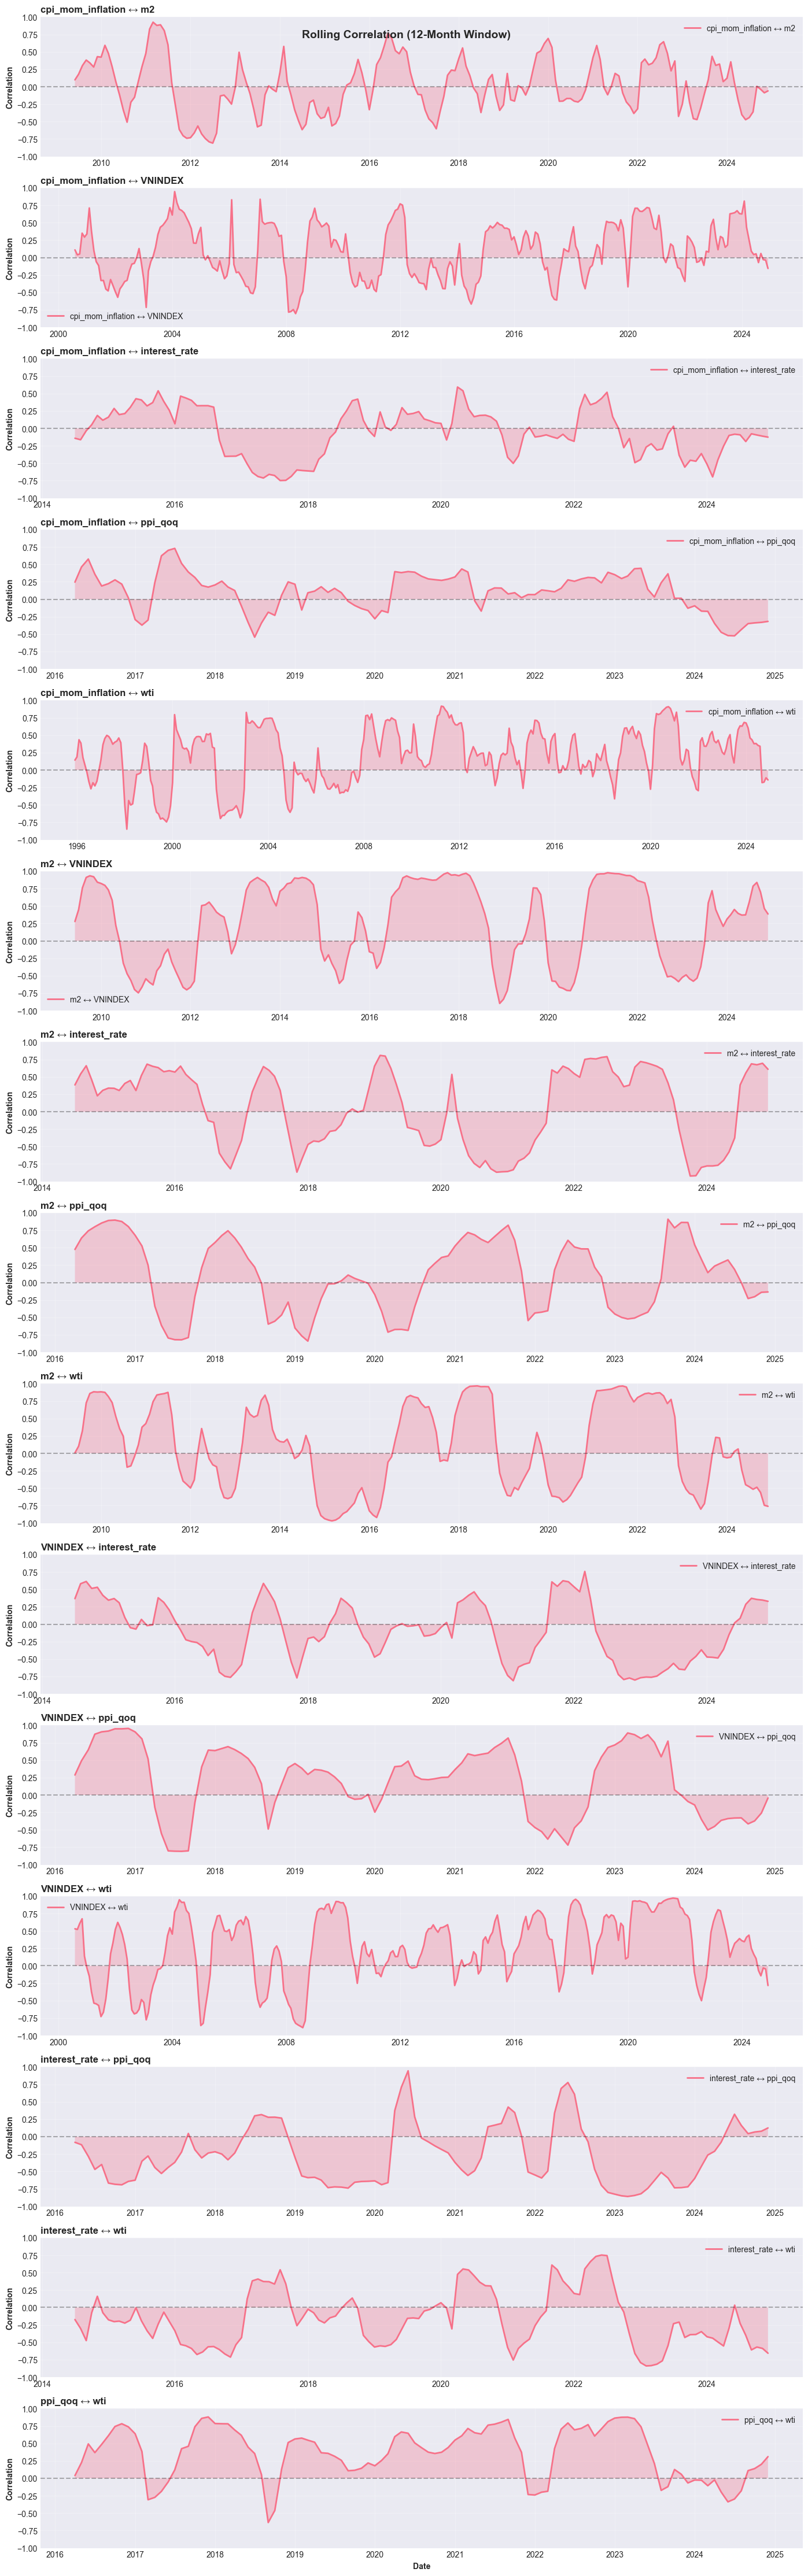

✓ Rolling correlation plotted for 15 variable pairs


In [104]:
# Select key variables for rolling correlation analysis
# Find columns that match key economic indicators
key_patterns = ['cpi_mom_inflation', 'm2', 'vnindex', 'interest', 'ppi','wti', 'gold', 'broad_money','policy_rate',
                'VNINDEX', 'S&P500', 'USDVND'] 
key_vars = []
for pattern in key_patterns:
    matches = [col for col in numeric_cols if pattern.lower() in col.lower()]
    if matches:
        key_vars.append(matches[0])

# Remove duplicates while preserving order
key_vars = list(dict.fromkeys(key_vars))
print(f"Key variables identified: {key_vars}")

# Limit to top 4 for visualization
key_vars = key_vars[:6]
print(f"Using for analysis: {key_vars}\n")

if len(key_vars) >= 2:
    # Calculate rolling correlation
    window = 12  # 12-month rolling window
    rolling_corr_list = []
    
    for i in range(len(key_vars)):
        for j in range(i+1, len(key_vars)):
            var1, var2 = key_vars[i], key_vars[j]
            rolling_corr = cleaned_data[var1].rolling(window=window).corr(cleaned_data[var2])
            rolling_corr_list.append((var1, var2, rolling_corr))
    
    # Plot rolling correlations
    fig, axes = plt.subplots(len(rolling_corr_list), 1, figsize=(14, 3*len(rolling_corr_list)))
    if len(rolling_corr_list) == 1:
        axes = [axes]
    
    fig.suptitle(f'Rolling Correlation (12-Month Window)', fontsize=14, fontweight='bold')
    
    for ax_idx, (var1, var2, rolling_corr) in enumerate(rolling_corr_list):
        axes[ax_idx].plot(cleaned_data['date'], rolling_corr, linewidth=2, label=f'{var1} ↔ {var2}')
        axes[ax_idx].axhline(y=0, color='k', linestyle='--', alpha=0.3)
        axes[ax_idx].fill_between(cleaned_data['date'], rolling_corr, 0, alpha=0.3)
        axes[ax_idx].set_ylabel('Correlation', fontweight='bold')
        axes[ax_idx].set_title(f'{var1} ↔ {var2}', fontweight='bold', loc='left')
        axes[ax_idx].grid(True, alpha=0.3)
        axes[ax_idx].legend(loc='best')
        axes[ax_idx].set_ylim([-1, 1])
    
    axes[-1].set_xlabel('Date', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Rolling correlation plotted for {len(rolling_corr_list)} variable pairs")
else:
    print("Not enough key variables for rolling correlation analysis")

Using: ['cpi_mom_inflation', 'm2', 'VNINDEX', 'interest_rate', 'ppi_qoq', 'wti']


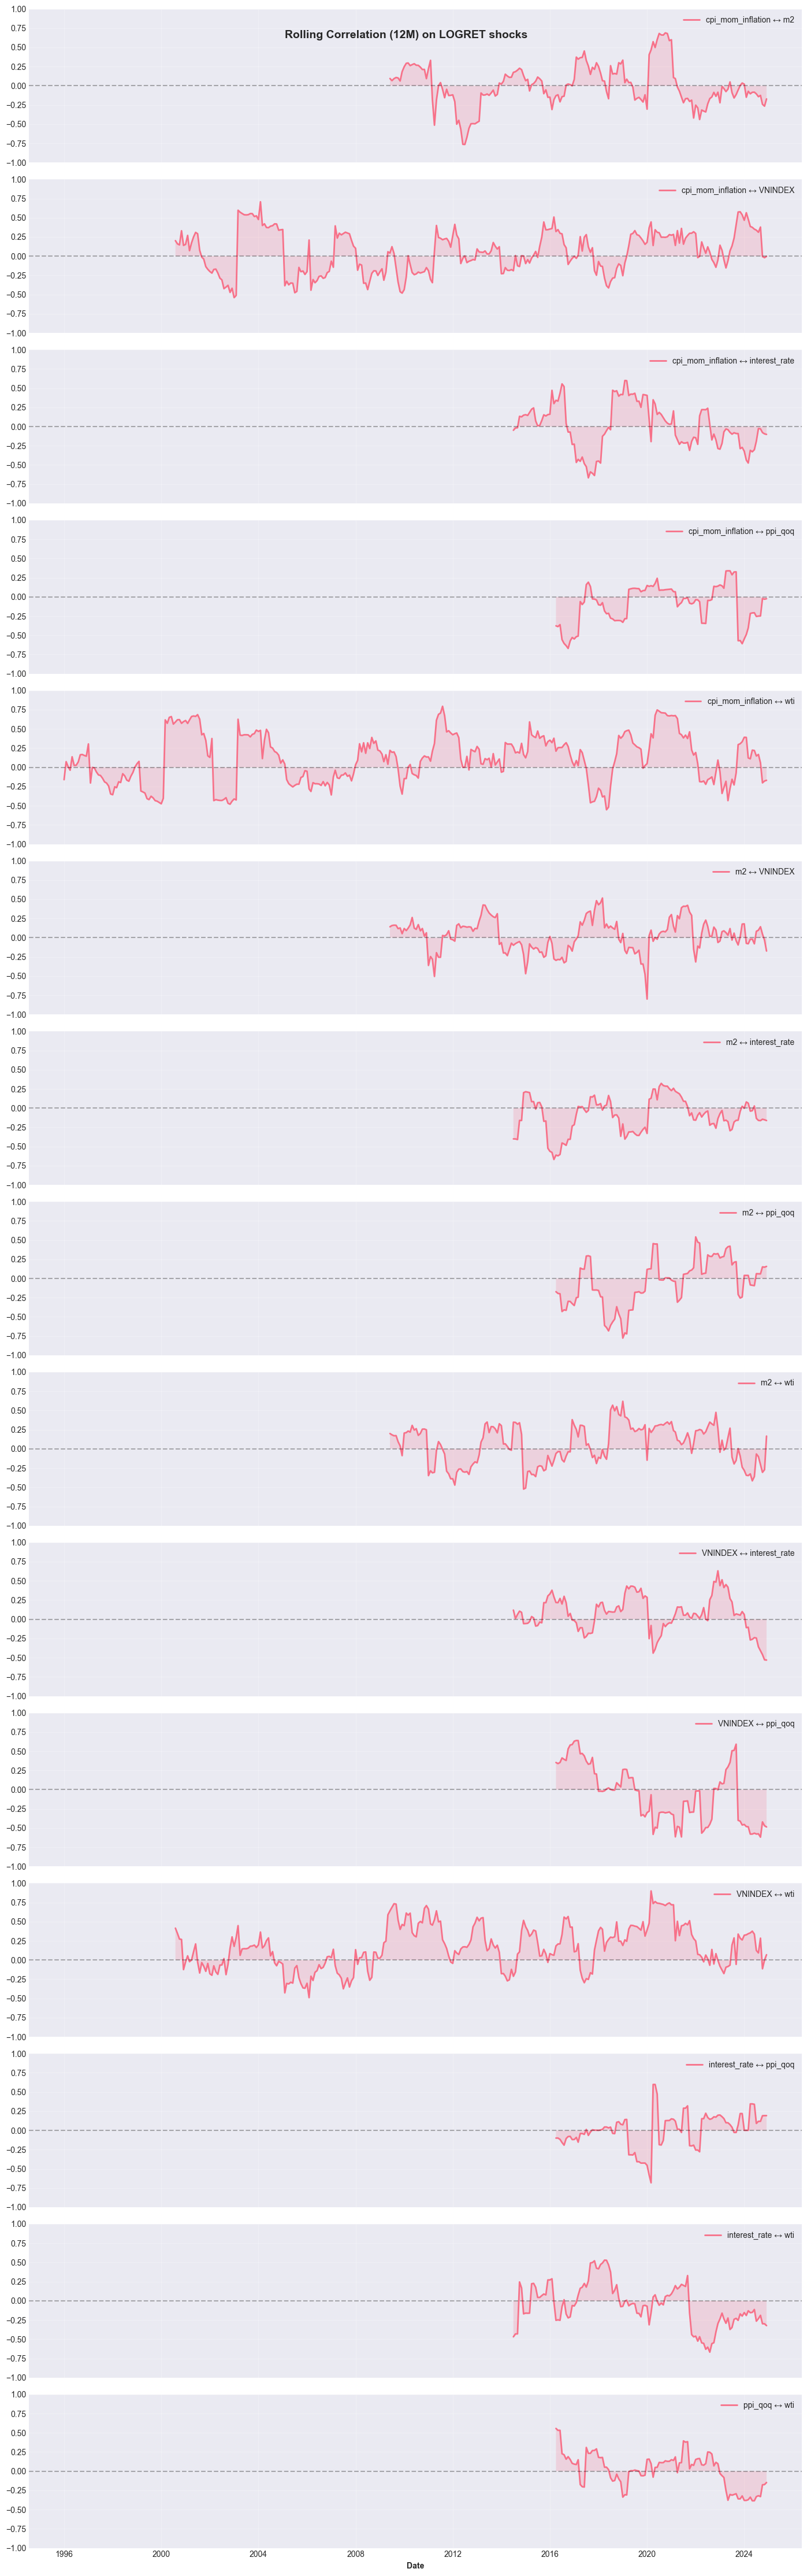

✓ Plotted 15 rolling correlations on logret shocks


In [105]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
df = cleaned_data.sort_values("date").copy()
num_cols = df.select_dtypes("number").columns

patterns = ['cpi_mom_inflation','m2','vnindex','interest','ppi','wti','gold','broad_money','policy_rate',
            'VNINDEX','S&P500','USDVND']

key_vars = []
for p in patterns:
    m = [c for c in num_cols if p.lower() in c.lower()]
    if m: key_vars.append(m[0])

key_vars = list(dict.fromkeys(key_vars))[:6]
print("Using:", key_vars)

# --- transform to short-run shocks ---
method = "logret"   # "diff" or "logret"
window = 12         # 12-month rolling window

def to_shock(s):
    if method == "diff":
        return s.diff()
    # log-return only if strictly positive; otherwise fallback to diff
    return np.log(s).diff() if (s > 0).all() else s.diff()

X = df[key_vars].apply(to_shock)
tmp = df[["date"]].join(X).dropna()

# --- rolling correlations & plot ---
pairs = list(combinations(key_vars, 2))
fig, axes = plt.subplots(len(pairs), 1, figsize=(14, 3*len(pairs)), sharex=True)
axes = np.atleast_1d(axes)

fig.suptitle(f"Rolling Correlation ({window}M) on {method.upper()} shocks", fontsize=14, fontweight="bold")

for ax, (a, b) in zip(axes, pairs):
    rc = tmp[a].rolling(window).corr(tmp[b])
    ax.plot(tmp["date"], rc, lw=2, label=f"{a} ↔ {b}")
    ax.axhline(0, color="k", ls="--", alpha=.3)
    ax.fill_between(tmp["date"], rc, 0, alpha=.2)
    ax.set_ylim(-1, 1)
    ax.grid(alpha=.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("Date", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"✓ Plotted {len(pairs)} rolling correlations on {method} shocks")

### 2.3 Lag Correlation Analysis (Lead-Lag Effects)

In [106]:
lag_results = []
target_var = ['cpi_mom_inflation']
key_vars = numeric_cols[1:24]
# Analyze lag effects for feture and target
if len(key_vars) >= 2:
    print(f"Analyzing lag correlations for: {key_vars}\n")
    
    for i in range(len(key_vars)):
        for j in range(len(key_vars)):
            if i != j:
                var1, var2 = target_var[0], key_vars[j]
                
                # Calculate correlation at different lags (0 to 12 months)
                for lag in range(0, 30):
                    if lag == 0:
                        corr = cleaned_data[var1].corr(cleaned_data[var2])
                    else:
                        corr = cleaned_data[var1].corr(cleaned_data[var2].shift(lag))
                    
                    lag_results.append({
                        'Var1': var1,
                        'Var2': var2,
                        'Lag': lag,
                        'Correlation': corr
                    })
    
    lag_df = pd.DataFrame(lag_results)
    lag_df['Correlation'] = lag_df['Correlation'].round(3)
    
    print(f"Lag correlation analysis complete")
   
    print(lag_df.to_string(index=False))
else:
    print("Not enough key variables for lag correlation analysis")

Analyzing lag correlations for: ['cpi_mom_inflation', 'core_inflation_rate', 'interest_rate', 'ppi_qoq', 'm2', 'broad_money', 'policy_rate', 'gdp', 'brent', 'wti', 'gasoline_world', 'natural_gas', 'gold', 'silver', 'VNINDEX', 'VN30', 'HNX', 'UPCOM', 'NASDAQ', 'S&P500', 'DAX', 'DOWJONES', 'NIKKEI225']

Lag correlation analysis complete
             Var1                Var2  Lag  Correlation
cpi_mom_inflation core_inflation_rate    0        0.022
cpi_mom_inflation core_inflation_rate    1       -0.008
cpi_mom_inflation core_inflation_rate    2       -0.008
cpi_mom_inflation core_inflation_rate    3       -0.008
cpi_mom_inflation core_inflation_rate    4        0.001
cpi_mom_inflation core_inflation_rate    5        0.010
cpi_mom_inflation core_inflation_rate    6        0.013
cpi_mom_inflation core_inflation_rate    7        0.025
cpi_mom_inflation core_inflation_rate    8        0.032
cpi_mom_inflation core_inflation_rate    9        0.032
cpi_mom_inflation core_inflation_rate   10     

In [107]:
target_var = ['cpi_mom_inflation']
key_vars = numeric_cols[1:31]
stat_vars = ['cpi_mom_cpi', 'cpi_mom_inflation', 'core_inflation_rate', 'interest_rate', 'brent', 'month', 'quarter']

if len(key_vars) >= 1:
    v1 = target_var[0]
    res = []
    
    for v2 in key_vars:
        if v2 == v1: 
            continue
        
        # Tự động lấy sai phân nếu biến thuộc nhóm không dừng
        s2 = cleaned_data[v2] if v2 in stat_vars else cleaned_data[v2].diff()
        
        for g in range(13):
            corr = cleaned_data[v1].corr(s2 if g == 0 else s2.shift(g))
            res.append({'Var1': v1, 'Var2': v2, 'Lag': g, 'Correlation': corr})
            
    df = pd.DataFrame(res)
    df['Abs'] = df['Correlation'].abs()
    out = df.sort_values('Abs', ascending=False).drop_duplicates('Var2')
    out['Correlation'] = out['Correlation'].round(3)
    print(out.drop(columns='Abs').to_string(index=False))

             Var1                Var2  Lag  Correlation
cpi_mom_inflation                year    1        0.399
cpi_mom_inflation         policy_rate    0        0.387
cpi_mom_inflation               month    2        0.354
cpi_mom_inflation               brent    0        0.326
cpi_mom_inflation             quarter    2        0.323
cpi_mom_inflation                 wti    1        0.267
cpi_mom_inflation           NIKKEI225    4       -0.191
cpi_mom_inflation              silver    1        0.179
cpi_mom_inflation      gasoline_world   11        0.150
cpi_mom_inflation                  m2   12       -0.146
cpi_mom_inflation                 HNX    1       -0.133
cpi_mom_inflation             VNINDEX    4       -0.129
cpi_mom_inflation         natural_gas    3        0.127
cpi_mom_inflation                gold    7        0.119
cpi_mom_inflation                 DAX    5       -0.118
cpi_mom_inflation         broad_money    3        0.117
cpi_mom_inflation              S&P500    5      

Chọn biến: cpi_mom_inflation, vnindex, broad_money, ppi_qoq, wti, gold, policy_rate, VNINDEX, NIKKEI225, USDVND

In [109]:
# Chọn biến: cpi_mom_inflation, vnindex, broad_money, ppi_qoq, wti, gold, policy_rate, VNINDEX, NIKKEI225, USDVND xuất ra csv
selected_vars = ['cpi_mom', 'policy_rate', 'broad_money', 'ppi_qoq', 'wti', 'gasoline_world', 'gold', 
                 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND','gdp']
selected_data = cleaned_data[['date'] + selected_vars]
print (selected_data.head())
selected_data.to_csv(os.path.join(DATA_DIR, 'cpi_02_06_selected_variables.csv'), index=False)
print(f"✓ Exported selected variables to 'cpi_02_06_selected_variables.csv'")

        date  cpi_mom  policy_rate  broad_money  ppi_qoq    wti  \
0 1995-01-01    103.8         10.8        3.567    -0.73  18.39   
1 1995-02-01    103.4         10.8        3.303    -0.73  18.49   
2 1995-03-01    100.2         10.8        3.495    -0.73  19.17   
3 1995-04-01    101.0         10.8        3.434    -0.73  20.38   
4 1995-05-01    101.8         10.8        3.247    -0.73  18.89   

   gasoline_world        gold  policy_rate  VNINDEX     NIKKEI225   USDVND  \
0           0.822  278.299988         10.8   101.55  18649.820312  11039.0   
1           0.822  278.299988         10.8   101.55  17053.429688  11050.0   
2           0.822  278.299988         10.8   101.55  16139.950195  11045.0   
3           0.822  278.299988         10.8   101.55  16806.750000  11041.0   
4           0.822  278.299988         10.8   101.55  15436.790039  11045.0   

        gdp  
0  434478.0  
1  434478.0  
2  434478.0  
3  434478.0  
4  434478.0  
✓ Exported selected variables to 'cpi_02_06_